## Постановка задачи

**1.1. Сгенерируйте выборку гауссовского распределения $N(5,3)$ с параметрами $m=5$, $\sigma^2=3$ объема $n=500$.**
- 1.1. Постройте доверительный интервал с уровнем доверия $0.95$ для:
    - 1.1.1 среднего, при известной дисперсии;
    - 1.1.2. Среднего при неизвестной дисперсии;
    - 1.1.3. дисперсии.

**2. По сгенерированной ранее нормальной выборке постройте группированную (статистический ряд).**
- 1.2. По группированной выборке постройте доверительные интервалы с уровнем доверия 0.95 для :
    - 1.2.1. среднего, при известной дисперсии;
    - 1.2.2 среднего при неизвестной дисперсии;
    - 1.2.3. дисперсии.

Сравните построенные интервалы в группированном и не группированном случаях.

**3. Постройте асимптотические доверительные интервалы с уровнем доверия 0.95 для:**
- 2.1.1. вероятности успеха в одном испытании для схемы Бернулли $B(0.3;n)$ для сгенерированной выборки большого объема $n=500$;
- 2.1.2. вероятности успеха в одном испытании для схемы Бернулли $B(0.3;n)$ для сгенерированной выборки среднего объема $n=50$;
- 2.2. параметра $λ$ Пуассоновского распределения $P(λ=2)$ для сгенерированной выборки объема $n=500$;
- 2.3. параметра $λ$ Показательного распределения ($λ=2$) для сгенерированной выборки объема $n=500$.


In [1]:
import numpy as np
import scipy.stats as st
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Генерация нормальной выборки $\mathcal{N}(5, 3)$, $n=500$

In [2]:
n = 500
mu = 5
sigma2 = 3
sigma = np.sqrt(sigma2)

sample = np.random.normal(mu, sigma, n)

x_bar = np.mean(sample)
s2 = np.var(sample, ddof=1)

print("Выборочное среднее:", x_bar)
print("Выборочная дисперсия:", s2)

Выборочное среднее: 5.01184375404942
Выборочная дисперсия: 2.8885738063745463


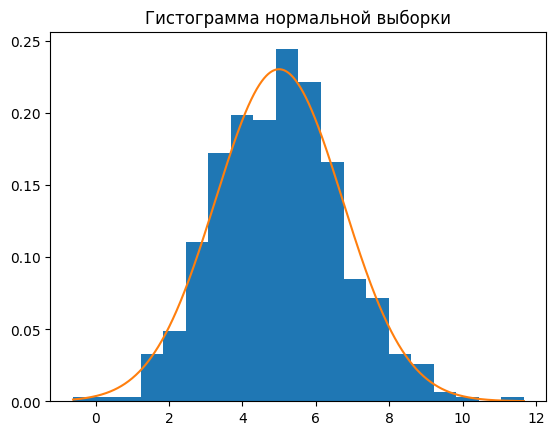

In [3]:
plt.figure()
plt.hist(sample, bins=20, density=True)
x = np.linspace(min(sample), max(sample), 1000)
plt.plot(x, st.norm.pdf(x, mu, sigma))
plt.title("Гистограмма нормальной выборки")
plt.show()

#### 1.1 Доверительные интервалы (негруппированная выборка)

In [ ]:
alpha = 0.05 
z = st.norm.ppf(1 - alpha/2)

# 1.1.1 Среднее, σ² известно
ci_mean_known = (
    x_bar - z*sigma/np.sqrt(n),
    x_bar + z*sigma/np.sqrt(n)
)

print("\nДИ для среднего (σ² известно):", ci_mean_known)

# 1.1.2 Среднее, σ² неизвестно
t = st.t.ppf(1 - alpha/2, df=n-1)
ci_mean_unknown = (
    x_bar - t*np.sqrt(s2)/np.sqrt(n),
    x_bar + t*np.sqrt(s2)/np.sqrt(n)
)

print("ДИ для среднего (σ² неизвестно):", ci_mean_unknown)

# 1.1.3 Дисперсия
chi2_left = st.chi2.ppf(alpha/2, df=n-1)
chi2_right = st.chi2.ppf(1 - alpha/2, df=n-1)

ci_var = (
    (n-1)*s2/chi2_right,
    (n-1)*s2/chi2_left
)

print("ДИ для дисперсии:", ci_var)


ДИ для среднего (σ² известно): (np.float64(4.860025596623621), np.float64(5.163661911475219))
ДИ для среднего (σ² неизвестно): (np.float64(4.862509487199412), np.float64(5.1611780208994285))
ДИ для дисперсии: (np.float64(2.561167789452301), np.float64(3.2833822836515667))


#### 1.2 Группированная выборка

In [5]:
k = int(np.sqrt(n))
counts, bins = np.histogram(sample, bins=k)
midpoints = (bins[:-1] + bins[1:]) / 2

grouped_mean = np.sum(midpoints * counts) / n
grouped_var = np.sum(counts * (midpoints - grouped_mean)**2) / (n - 1)

print("\nГруппированное среднее:", grouped_mean)
print("Группированная дисперсия:", grouped_var)


Группированное среднее: 5.014599514085041
Группированная дисперсия: 2.8904898803084764


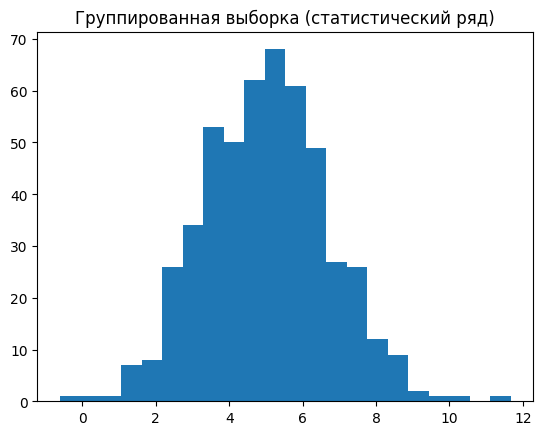

In [6]:
plt.figure()
plt.hist(sample, bins=k)
plt.title("Группированная выборка (статистический ряд)")
plt.show()

#### Доверительные интервалы (группированная выборка)

In [7]:
ci_g_mean_known = (
    grouped_mean - z*sigma/np.sqrt(n),
    grouped_mean + z*sigma/np.sqrt(n)
)

ci_g_mean_unknown = (
    grouped_mean - t*np.sqrt(grouped_var)/np.sqrt(n),
    grouped_mean + t*np.sqrt(grouped_var)/np.sqrt(n)
)

ci_g_var = (
    (n-1)*grouped_var/chi2_right,
    (n-1)*grouped_var/chi2_left
)

print("\nДИ среднего (групп., σ² известно):", ci_g_mean_known)
print("ДИ среднего (групп., σ² неизвестно):", ci_g_mean_unknown)
print("ДИ дисперсии (групп.):", ci_g_var)


ДИ среднего (групп., σ² известно): (np.float64(4.862781356659242), np.float64(5.16641767151084))
ДИ среднего (групп., σ² неизвестно): (np.float64(4.865215726592565), np.float64(5.163983301577517))
ДИ дисперсии (групп.): (np.float64(2.5628666855756967), np.float64(3.285560245383045))


## 2. Асимптотические интервалы

In [ ]:
n1 = 500
p_true = 0.3

bern1 = np.random.binomial(1, p_true, n1)
p_hat1 = np.mean(bern1)

ci_bern1 = (
    p_hat1 - z*np.sqrt(p_hat1*(1-p_hat1)/n1),
    p_hat1 + z*np.sqrt(p_hat1*(1-p_hat1)/n1)
)

print("\nБернулли n=500")
print("Оценка p:", p_hat1)
print("ДИ:", ci_bern1)


Бернулли n=500
Оценка p: 0.298
ДИ: (np.float64(0.25790965653791603), np.float64(0.33809034346208394))


In [15]:
n2 = 50
bern2 = np.random.binomial(1, p_true, n2)
p_hat2 = np.mean(bern2)

ci_bern2 = (
    p_hat2 - z*np.sqrt(p_hat2*(1-p_hat2)/n2),
    p_hat2 + z*np.sqrt(p_hat2*(1-p_hat2)/n2)
)

print("\nБернулли n=50")
print("Оценка p:", p_hat2)
print("ДИ:", ci_bern2)


Бернулли n=50
Оценка p: 0.14
ДИ: (np.float64(0.043821869220537185), np.float64(0.23617813077946284))


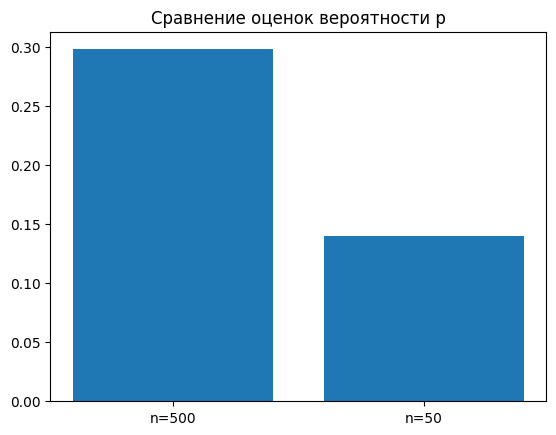

In [16]:
plt.figure()
plt.bar(["n=500", "n=50"], [p_hat1, p_hat2])
plt.title("Сравнение оценок вероятности p")
plt.show()

In [17]:
lam_true = 2
pois = np.random.poisson(lam_true, 500)
lam_hat_pois = np.mean(pois)

ci_pois = (
    lam_hat_pois - z*np.sqrt(lam_hat_pois/500),
    lam_hat_pois + z*np.sqrt(lam_hat_pois/500)
)

print("\nПуассон λ=2")
print("Оценка λ:", lam_hat_pois)
print("ДИ:", ci_pois)


Пуассон λ=2
Оценка λ: 2.0
ДИ: (np.float64(1.8760409935390876), np.float64(2.1239590064609124))


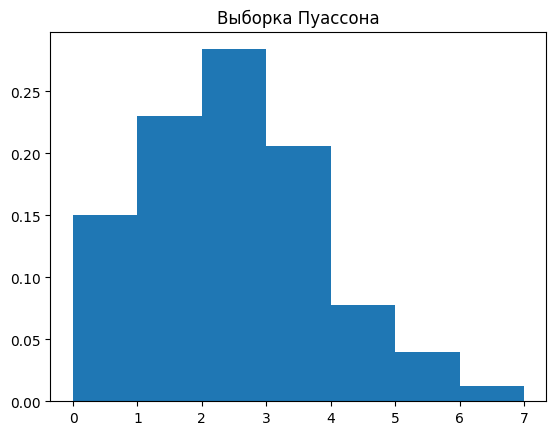

In [18]:
plt.figure()
plt.hist(pois, bins=range(0, max(pois)+2), density=True)
plt.title("Выборка Пуассона")
plt.show()

In [19]:
exp_sample = np.random.exponential(1/lam_true, 500)
lam_hat_exp = 1/np.mean(exp_sample)

ci_exp = (
    lam_hat_exp - z*lam_hat_exp/np.sqrt(500),
    lam_hat_exp + z*lam_hat_exp/np.sqrt(500)
)

print("\nПоказательное λ=2")
print("Оценка λ:", lam_hat_exp)
print("ДИ:", ci_exp)


Показательное λ=2
Оценка λ: 2.048764858167539
ДИ: (np.float64(1.869186000315036), np.float64(2.228343716020042))


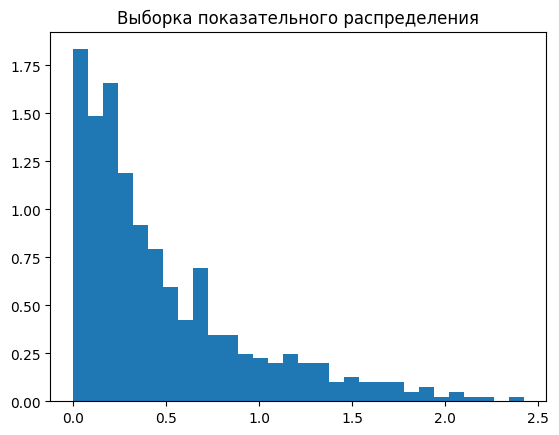

In [20]:
plt.figure()
plt.hist(exp_sample, bins=30, density=True)
plt.title("Выборка показательного распределения")
plt.show()